In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [134]:
Heart_data = pd.read_csv("heart_attack_prediction_dataset.csv")

In [135]:
Heart_data.head(10)

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0
5,ZOO7941,54,Female,297,172/86,48,1,1,1,0,...,7.798752,241339,20.146840,795,5,10,Germany,Europe,Northern Hemisphere,1
6,WYV0966,90,Male,358,102/73,84,0,0,1,0,...,0.627356,190450,28.885811,284,4,10,Canada,North America,Northern Hemisphere,1
7,XXM0972,84,Male,220,131/68,107,0,0,1,1,...,10.543780,122093,22.221862,370,6,7,Japan,Asia,Northern Hemisphere,1
8,XCQ5937,20,Male,145,144/105,68,1,0,1,1,...,11.348787,25086,35.809901,790,7,4,Brazil,South America,Southern Hemisphere,0
9,FTJ5456,43,Female,248,160/70,55,0,1,1,1,...,4.055115,209703,22.558917,232,7,7,Japan,Asia,Northern Hemisphere,0


In [136]:
Heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [137]:
Heart_data.isnull().sum()

Patient ID                         0
Age                                0
Sex                                0
Cholesterol                        0
Blood Pressure                     0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Country                            0
Continent                          0
Hemisphere                         0
Heart Attack Risk                  0
dtype: int64

In [138]:
Heart_data.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,53.707977,259.877211,75.021682,0.652288,0.492982,0.896839,0.501426,0.598083,10.014284,0.495835,0.498345,5.469702,5.993690,158263.181901,28.891446,417.677051,3.489672,7.023508,0.358211
std,21.249509,80.863276,20.550948,0.476271,0.499979,0.304186,0.500026,0.490313,5.783745,0.500011,0.500026,2.859622,3.466359,80575.190806,6.319181,223.748137,2.282687,1.988473,0.479502
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,0.000000,0.000000,1.000000,0.001263,20062.000000,18.002337,30.000000,0.000000,4.000000,0.000000
25%,35.000000,192.000000,57.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.981579,0.000000,0.000000,3.000000,2.998794,88310.000000,23.422985,225.500000,2.000000,5.000000,0.000000
50%,54.000000,259.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.069559,0.000000,0.000000,5.000000,5.933622,157866.000000,28.768999,417.000000,3.000000,7.000000,0.000000
75%,72.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.050018,1.000000,1.000000,8.000000,9.019124,227749.000000,34.324594,612.000000,5.000000,9.000000,1.000000
max,90.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,1.000000,10.000000,11.999313,299954.000000,39.997211,800.000000,7.000000,10.000000,1.000000


# New Data Set Creation For the Analysis

In [139]:
new_df = Heart_data[['Age','Sex','Cholesterol','Blood Pressure','Heart Rate','Diabetes','Family History','Smoking','Obesity','Alcohol Consumption','Exercise Hours Per Week','Diet',
'Previous Heart Problems','Stress Level','Sedentary Hours Per Day','Triglycerides','Physical Activity Days Per Week','Sleep Hours Per Day','Heart Attack Risk']].copy()

In [140]:
new_df.head()

,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Stress Level,Sedentary Hours Per Day,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
0,67,Male,208,158/88,72,0,0,1,0,0,4.168189,Average,0,9,6.615001,286,0,6,0
1,21,Male,389,165/93,98,1,1,1,1,1,1.813242,Unhealthy,1,1,4.963459,235,1,7,0
2,21,Female,324,174/99,72,1,0,0,0,0,2.078353,Healthy,1,9,9.463426,587,4,4,0
3,84,Male,383,163/100,73,1,1,1,0,1,9.828130,Average,1,9,7.648981,378,3,4,0
4,66,Male,318,91/88,93,1,1,1,1,0,5.804299,Unhealthy,1,6,1.514821,231,1,5,0


In [141]:
binary_cols = ['Diabetes','Family History','Smoking','Obesity','Alcohol Consumption','Previous Heart Problems','Heart Attack Risk']

In [142]:
def conversion(x):
    if x==1:
        return 'Yes'
    else:
        return 'No'

In [143]:
for x in binary_cols:
    new_df[x] = new_df[x].apply(conversion)

In [144]:
new_df['Blood_Pressure_Systolic'] = new_df['Blood Pressure'].str.split('/',expand=True)[0]
new_df['Blood_Pressure_Diastolic'] = new_df['Blood Pressure'].str.split('/',expand=True)[1]

In [145]:
new_df.drop(columns=['Blood Pressure'],inplace= True)

In [146]:
new_df.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Stress Level,Sedentary Hours Per Day,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Blood_Pressure_Systolic,Blood_Pressure_Diastolic
0,67,Male,208,72,No,No,Yes,No,No,4.168189,Average,No,9,6.615001,286,0,6,No,158,88
1,21,Male,389,98,Yes,Yes,Yes,Yes,Yes,1.813242,Unhealthy,Yes,1,4.963459,235,1,7,No,165,93
2,21,Female,324,72,Yes,No,No,No,No,2.078353,Healthy,Yes,9,9.463426,587,4,4,No,174,99
3,84,Male,383,73,Yes,Yes,Yes,No,Yes,9.828130,Average,Yes,9,7.648981,378,3,4,No,163,100
4,66,Male,318,93,Yes,Yes,Yes,Yes,No,5.804299,Unhealthy,Yes,6,1.514821,231,1,5,No,91,88


In [147]:
col = new_df.pop('Blood_Pressure_Systolic')
new_df.insert(3,'Blood_Pressure_Systolic',col)

col1 = new_df.pop('Blood_Pressure_Diastolic')
new_df.insert(4,'Blood_Pressure_Diastolic',col1)

In [148]:
def sleep(x):
    if x==1 or x==2 or x==3 or x==4:
        return 'Light'
    elif x==5 or x==6:
        return 'Moderate'
    else:
        return 'Healthy'

In [149]:
new_df['Sleep Hours Per Day'] = new_df['Sleep Hours Per Day'].apply(sleep)

In [150]:
def Fat(x):
    if x<150:
        return 'Normal'
    elif x>=150 and x<=199:
        return 'Borderline'
    elif x>=200 and x<=499:
        return 'High'
    else:
        return 'Very High' 

In [151]:
new_df['Triglycerides'] = new_df['Triglycerides'].apply(Fat)

In [152]:
def stress(x):
    if x==1 or x==2 or x==3:
        return 'Normal'
    elif x==4 or x==5 or x==6:
        return 'Moderate'
    elif x==7:
        return 'Little High'
    else:
        return 'Extreme' 

In [153]:
new_df['Stress Level'] = new_df['Stress Level'].apply(stress)

In [154]:
new_df['Exercise Hours Per Week'] = np.ceil(new_df['Exercise Hours Per Week']).astype(int)

In [155]:
new_df['Sedentary Hours Per Day'] = np.ceil(new_df['Sedentary Hours Per Day']).astype(int)

In [156]:
new_df.head()

,Age,Sex,Cholesterol,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Stress Level,Sedentary Hours Per Day,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
0,67,Male,208,158,88,72,No,No,Yes,No,No,5,Average,No,Extreme,7,High,0,Moderate,No
1,21,Male,389,165,93,98,Yes,Yes,Yes,Yes,Yes,2,Unhealthy,Yes,Normal,5,High,1,Healthy,No
2,21,Female,324,174,99,72,Yes,No,No,No,No,3,Healthy,Yes,Extreme,10,Very High,4,Light,No
3,84,Male,383,163,100,73,Yes,Yes,Yes,No,Yes,10,Average,Yes,Extreme,8,High,3,Light,No
4,66,Male,318,91,88,93,Yes,Yes,Yes,Yes,No,6,Unhealthy,Yes,Moderate,2,High,1,Moderate,No


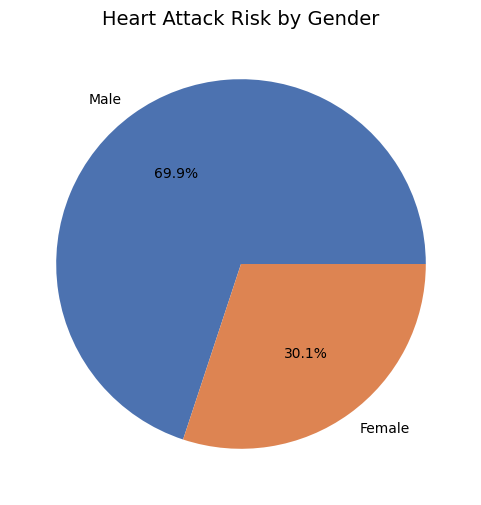

In [157]:
sex_df = new_df[new_df['Heart Attack Risk'] == 'Yes']
label = ['Male','Female']
plt.figure(figsize=(6,6))
plt.pie(sex_df['Sex'].value_counts(),labels=label,autopct='%1.1f%%',colors=['#4C72B0','#DD8452'])
plt.title('Heart Attack Risk by Gender', fontsize=14)
plt.show()
